SIMULATION PARAMETERS
Sample size per group: 1000
Control group conversion rate: 12.0%
Expected lift: 3.0%
Variant group conversion rate: 15.0%
Total sample size: 2000

GENERATING MOCK A/B TEST DATA
First 10 rows of A/B test data:


,user_id,group,converted,conversion_rate
0,1,Control,0,0.12
1,2,Control,1,0.12
2,3,Control,0,0.12
3,4,Control,0,0.12
4,5,Control,0,0.12
5,6,Control,0,0.12
6,7,Control,0,0.12
7,8,Control,0,0.12
8,9,Control,0,0.12
9,10,Control,0,0.12


ACTUAL CONVERSION RATES FROM SIMULATED DATA
Control group conversion rate: 0.124 (12.4%)
Variant group conversion rate: 0.152 (15.2%)
Absolute lift: 0.0280 (2.8%)
Relative lift: 22.58%

SUMMARY STATISTICS


,count,conversions,conversion_rate,std_dev
group,,,,
Control,1000,124,0.124,0.3297
Variant,1000,152,0.152,0.3592


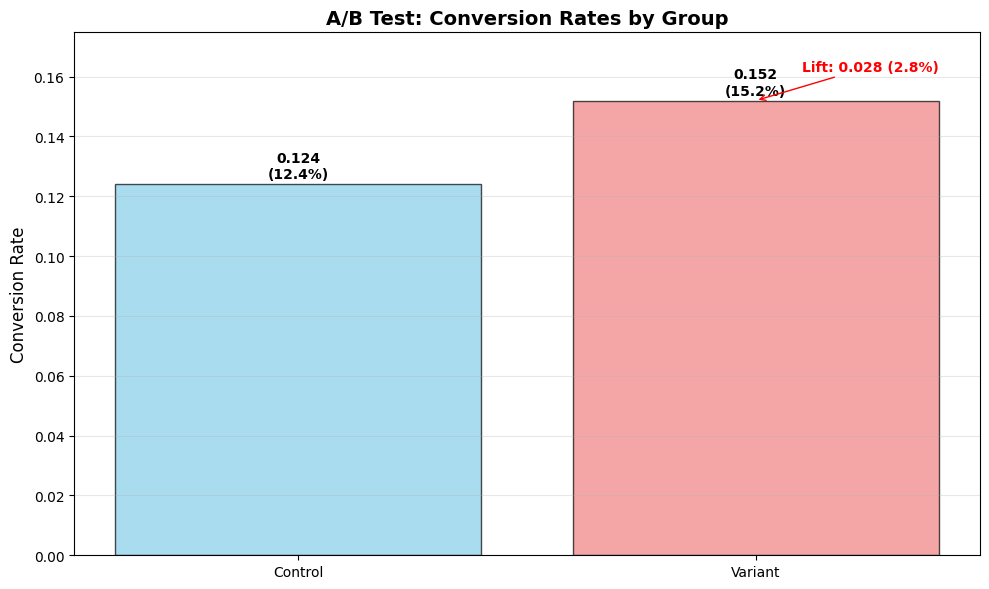

STATISTICAL SIGNIFICANCE TESTING
T-statistic: 1.8159
P-value: 0.0348
Significance level (α): 0.05

Statistical Significance: True
✅ Result: STATISTICALLY SIGNIFICANT - Reject the null hypothesis
The variant group performs significantly better than the control group.

CONFIDENCE INTERVALS
Control Group: 0.124 (0.104 - 0.144)
Variant Group: 0.152 (0.130 - 0.174)


C:\Users\sarum\AppData\Local\Temp\ipykernel_18320\1599706260.py:195: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(conversion_data, labels=groups, patch_artist=True,


<Figure size 1200x800 with 0 Axes>

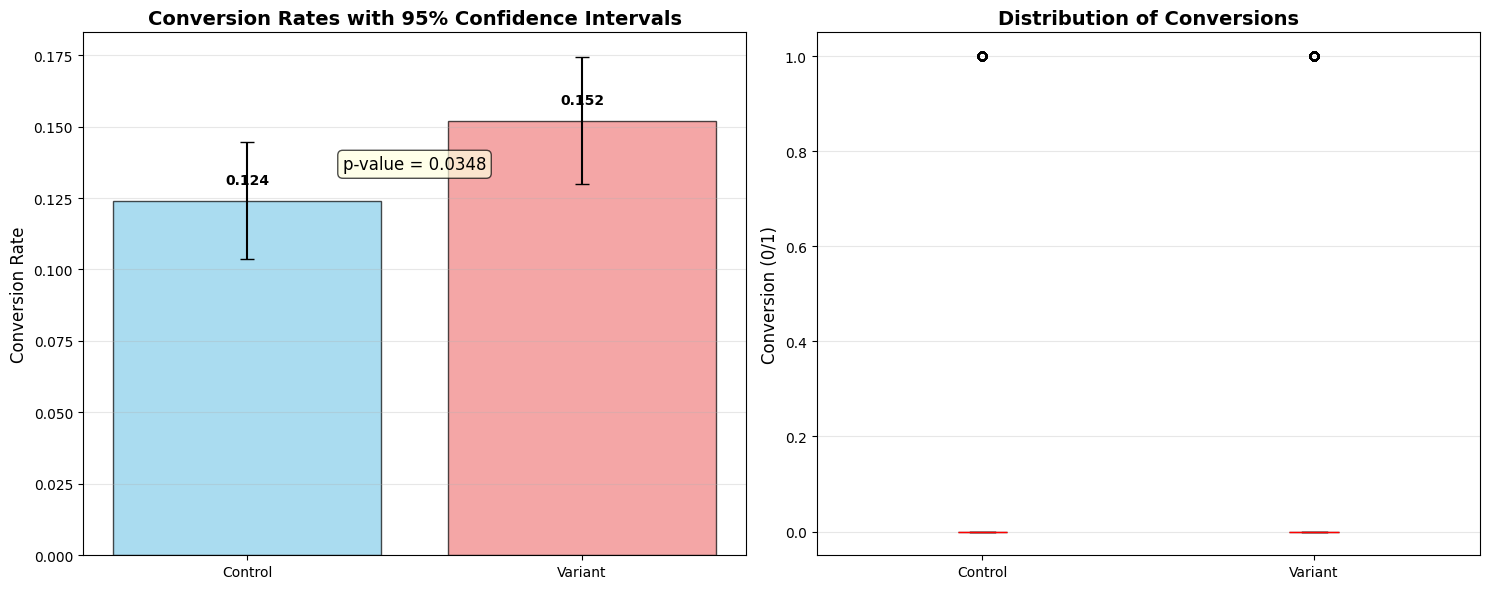


POWER ANALYSIS
Observed effect size: 0.0280
Pooled standard deviation: 0.3446
Statistical power: 0.0959
⚠️  Low statistical power - consider increasing sample size

SAMPLE SIZE CALCULATION FOR FUTURE TESTS
Required sample size per group for 80% power: 20024
Total required sample size: 40048
⚠️  Need larger sample size: 19024 more users per group

BAYESIAN ANALYSIS (ADDITIONAL INSIGHTS)
Bayesian Estimate - Control: 0.1248 ± 0.0104
Bayesian Estimate - Variant: 0.1527 ± 0.0114
Probability that variant is better than control: 96.5%


C:\Users\sarum\AppData\Local\Temp\ipykernel_18320\1599706260.py:392: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x1000 with 0 Axes>

C:\Users\sarum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sarum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sarum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


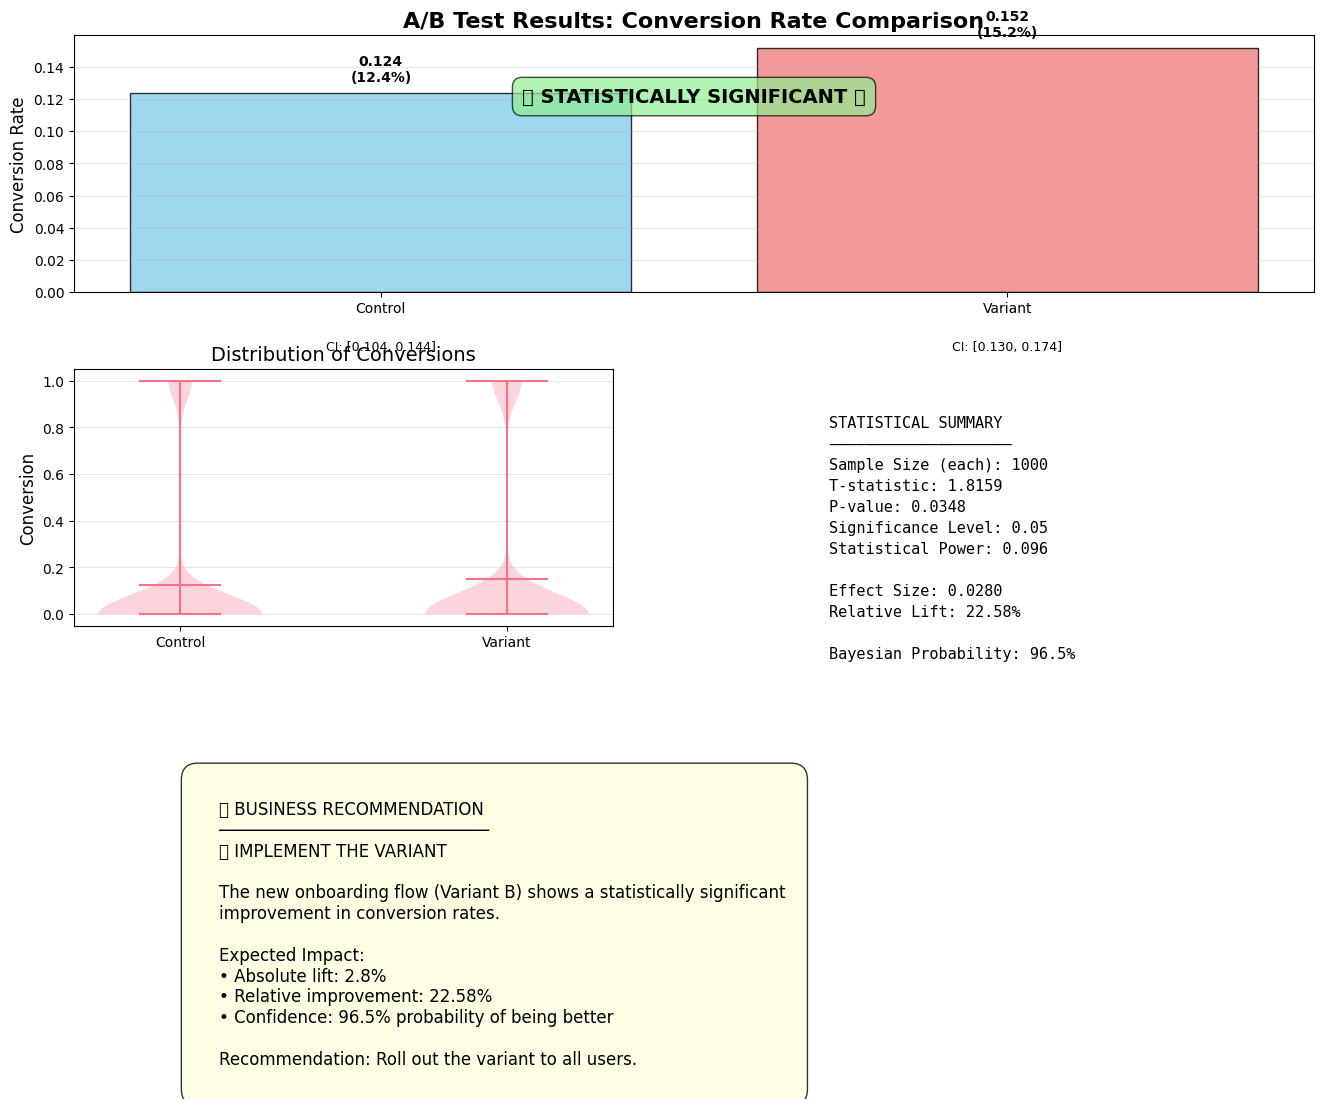


ANALYSIS COMPLETE - RESULTS SAVED
📊 Files saved:
   - ab_test_results.csv: Raw A/B test data
   - ab_test_summary.csv: Summary statistics
📈 Result: STATISTICALLY SIGNIFICANT
💡 Recommendation: Implement variant


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import ttest_ind, norm
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")
print("SIMULATION PARAMETERS")
print("=" * 50)

# Sample size per group
sample_size = 1000

# Baseline conversion rate for control group
control_conversion_rate = 0.12  # 12%

# Expected lift for variant group
expected_lift = 0.03  # 3% absolute lift

# Variant conversion rate
variant_conversion_rate = control_conversion_rate + expected_lift

print(f"Sample size per group: {sample_size}")
print(f"Control group conversion rate: {control_conversion_rate:.1%}")
print(f"Expected lift: {expected_lift:.1%}")
print(f"Variant group conversion rate: {variant_conversion_rate:.1%}")
print(f"Total sample size: {sample_size * 2}")

# %%
# Generate mock A/B test data
print("\nGENERATING MOCK A/B TEST DATA")
print("=" * 50)

# Control group data
control_conversions = np.random.binomial(1, control_conversion_rate, sample_size)
control_group = pd.DataFrame({
    'user_id': range(1, sample_size + 1),
    'group': 'Control',
    'converted': control_conversions,
    'conversion_rate': control_conversion_rate
})

# Variant group data (with slightly higher conversion rate)
variant_conversions = np.random.binomial(1, variant_conversion_rate, sample_size)
variant_group = pd.DataFrame({
    'user_id': range(sample_size + 1, sample_size * 2 + 1),
    'group': 'Variant',
    'converted': variant_conversions,
    'conversion_rate': variant_conversion_rate
})

# Combine both groups
ab_test_data = pd.concat([control_group, variant_group], ignore_index=True)

print("First 10 rows of A/B test data:")
display(ab_test_data.head(10))

# %%
# Calculate actual conversion rates from simulated data
actual_control_rate = control_group['converted'].mean()
actual_variant_rate = variant_group['converted'].mean()
actual_lift = actual_variant_rate - actual_control_rate
relative_lift = (actual_variant_rate - actual_control_rate) / actual_control_rate

print("ACTUAL CONVERSION RATES FROM SIMULATED DATA")
print("=" * 50)
print(f"Control group conversion rate: {actual_control_rate:.3f} ({actual_control_rate:.1%})")
print(f"Variant group conversion rate: {actual_variant_rate:.3f} ({actual_variant_rate:.1%})")
print(f"Absolute lift: {actual_lift:.4f} ({actual_lift:.1%})")
print(f"Relative lift: {relative_lift:.2%}")

# %%
# Summary statistics
print("\nSUMMARY STATISTICS")
print("=" * 50)

summary_stats = ab_test_data.groupby('group')['converted'].agg([
    ('count', 'count'),
    ('conversions', 'sum'),
    ('conversion_rate', 'mean'),
    ('std_dev', 'std')
]).round(4)

display(summary_stats)
plt.figure(figsize=(10, 6))
groups = ['Control', 'Variant']
conversion_rates = [actual_control_rate, actual_variant_rate]

bars = plt.bar(groups, conversion_rates, color=['skyblue', 'lightcoral'], alpha=0.7, edgecolor='black')

# Add value labels on top of bars
for bar, rate in zip(bars, conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{rate:.3f}\n({rate:.1%})', 
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Conversion Rate', fontsize=12)
plt.title('A/B Test: Conversion Rates by Group', fontsize=14, fontweight='bold')
plt.ylim(0, max(conversion_rates) * 1.15)
plt.grid(axis='y', alpha=0.3)

# Add lift annotation
plt.annotate(f'Lift: {actual_lift:.3f} ({actual_lift:.1%})', 
             xy=(1, actual_variant_rate), 
             xytext=(1.1, actual_variant_rate + 0.01),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontweight='bold', color='red')

plt.tight_layout()
plt.show()
print("STATISTICAL SIGNIFICANCE TESTING")
print("=" * 50)

# Extract conversion data for both groups
control_conversions = control_group['converted']
variant_conversions = variant_group['converted']

# Perform independent t-test
t_stat, p_value = ttest_ind(variant_conversions, control_conversions, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significance level (α): 0.05")

# Determine statistical significance
is_significant = p_value < 0.05

print(f"\nStatistical Significance: {is_significant}")
if is_significant:
    print("✅ Result: STATISTICALLY SIGNIFICANT - Reject the null hypothesis")
    print("The variant group performs significantly better than the control group.")
else:
    print("❌ Result: NOT STATISTICALLY SIGNIFICANT - Fail to reject the null hypothesis")
    print("There is no significant difference between the groups.")

# %%
# Calculate confidence intervals
print("\nCONFIDENCE INTERVALS")
print("=" * 50)

def calculate_confidence_interval(conversions, confidence=0.95):
    n = len(conversions)
    p = conversions.mean()
    se = np.sqrt(p * (1 - p) / n)
    z_value = norm.ppf((1 + confidence) / 2)
    margin_of_error = z_value * se
    return p, p - margin_of_error, p + margin_of_error

# Calculate for both groups
control_rate, control_ci_lower, control_ci_upper = calculate_confidence_interval(control_conversions)
variant_rate, variant_ci_lower, variant_ci_upper = calculate_confidence_interval(variant_conversions)

print(f"Control Group: {control_rate:.3f} ({control_ci_lower:.3f} - {control_ci_upper:.3f})")
print(f"Variant Group: {variant_rate:.3f} ({variant_ci_lower:.3f} - {variant_ci_upper:.3f})")

# %%
# Enhanced visualization with statistical information
plt.figure(figsize=(12, 8))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Conversion rates with confidence intervals
groups = ['Control', 'Variant']
rates = [control_rate, variant_rate]
ci_lower = [control_ci_lower, variant_ci_lower]
ci_upper = [control_ci_upper, variant_ci_upper]

bars = ax1.bar(groups, rates, color=['skyblue', 'lightcoral'], alpha=0.7, 
               yerr=[rates[i] - ci_lower[i] for i in range(2)], 
               capsize=5, edgecolor='black')

# Add value labels
for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{rate:.3f}', ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel('Conversion Rate', fontsize=12)
ax1.set_title('Conversion Rates with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add p-value annotation
ax1.text(0.5, max(rates) * 0.9, f'p-value = {p_value:.4f}', 
         ha='center', va='center', fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.7))

# Plot 2: Distribution of conversions
conversion_data = [control_conversions, variant_conversions]
ax2.boxplot(conversion_data, labels=groups, patch_artist=True,
            boxprops=dict(facecolor='lightgray', alpha=0.7),
            medianprops=dict(color='red'))
ax2.set_ylabel('Conversion (0/1)', fontsize=12)
ax2.set_title('Distribution of Conversions', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Power analysis
print("\nPOWER ANALYSIS")
print("=" * 50)

# Calculate observed effect size
effect_size = actual_variant_rate - actual_control_rate
pooled_std = np.sqrt((control_rate * (1 - control_rate) + variant_rate * (1 - variant_rate)) / 2)

print(f"Observed effect size: {effect_size:.4f}")
print(f"Pooled standard deviation: {pooled_std:.4f}")

# Estimate statistical power
from statsmodels.stats.power import TTestIndPower

# Parameters for power analysis
effect_size_abs = abs(effect_size)
alpha = 0.05
nobs1 = sample_size

# Perform power analysis
power_analysis = TTestIndPower()
power = power_analysis.power(effect_size=effect_size_abs, nobs1=nobs1, alpha=alpha, ratio=1.0)

print(f"Statistical power: {power:.4f}")

if power >= 0.8:
    print("✅ Sufficient statistical power (≥ 0.8)")
else:
    print("⚠️  Low statistical power - consider increasing sample size")

# %%
# Sample size calculation for future tests
print("\nSAMPLE SIZE CALCULATION FOR FUTURE TESTS")
print("=" * 50)

# Calculate required sample size for 80% power
required_n = power_analysis.solve_power(effect_size=effect_size_abs, power=0.8, alpha=0.05, ratio=1.0)
required_n = int(np.ceil(required_n))

print(f"Required sample size per group for 80% power: {required_n}")
print(f"Total required sample size: {required_n * 2}")

if sample_size >= required_n:
    print("✅ Current sample size is sufficient")
else:
    print(f"⚠️  Need larger sample size: {required_n - sample_size} more users per group")

# %%
# Bayesian approach for additional insights
print("\nBAYESIAN ANALYSIS (ADDITIONAL INSIGHTS)")
print("=" * 50)

# Simple Bayesian estimation
def bayesian_estimation(successes, trials, alpha_prior=1, beta_prior=1):
    """Calculate Bayesian posterior distribution"""
    alpha_post = alpha_prior + successes
    beta_post = beta_prior + trials - successes
    posterior_mean = alpha_post / (alpha_post + beta_post)
    posterior_std = np.sqrt((alpha_post * beta_post) / 
                          ((alpha_post + beta_post) ** 2 * (alpha_post + beta_post + 1)))
    return posterior_mean, posterior_std

# Calculate Bayesian estimates
control_success = control_conversions.sum()
control_trials = len(control_conversions)
variant_success = variant_conversions.sum()
variant_trials = len(variant_conversions)

control_bayes_mean, control_bayes_std = bayesian_estimation(control_success, control_trials)
variant_bayes_mean, variant_bayes_std = bayesian_estimation(variant_success, variant_trials)

print(f"Bayesian Estimate - Control: {control_bayes_mean:.4f} ± {control_bayes_std:.4f}")
print(f"Bayesian Estimate - Variant: {variant_bayes_mean:.4f} ± {variant_bayes_std:.4f}")

# Probability that variant is better than control
from scipy.stats import beta

control_beta = beta(control_success + 1, control_trials - control_success + 1)
variant_beta = beta(variant_success + 1, variant_trials - variant_success + 1)

prob_variant_better = 0
samples = 10000
for _ in range(samples):
    if variant_beta.rvs() > control_beta.rvs():
        prob_variant_better += 1

prob_variant_better /= samples

print(f"Probability that variant is better than control: {prob_variant_better:.1%}")

# %%
# Final comprehensive visualization
plt.figure(figsize=(14, 10))

# Create a comprehensive results dashboard
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Main conversion rates
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.bar(groups, rates, color=['skyblue', 'lightcoral'], alpha=0.8, edgecolor='black')
ax1.set_ylabel('Conversion Rate', fontsize=12)
ax1.set_title('A/B Test Results: Conversion Rate Comparison', fontsize=16, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add detailed annotations
for i, (bar, rate, ci_low, ci_high) in enumerate(zip(bars, rates, ci_lower, ci_upper)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{rate:.3f}\n({rate:.1%})', ha='center', va='bottom', fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2, -0.03, 
             f'CI: [{ci_low:.3f}, {ci_high:.3f}]', ha='center', va='top', fontsize=9)

# Add statistical significance marker
if is_significant:
    ax1.text(0.5, max(rates) * 0.8, '⭐ STATISTICALLY SIGNIFICANT ⭐', 
             ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

# Plot 2: Distribution
ax2 = fig.add_subplot(gs[1, 0])
violin_parts = ax2.violinplot(conversion_data, showmeans=True)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(groups)
ax2.set_ylabel('Conversion', fontsize=12)
ax2.set_title('Distribution of Conversions', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Statistical summary
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
stats_text = f"""
STATISTICAL SUMMARY
────────────────────
Sample Size (each): {sample_size}
T-statistic: {t_stat:.4f}
P-value: {p_value:.4f}
Significance Level: 0.05
Statistical Power: {power:.3f}

Effect Size: {effect_size:.4f}
Relative Lift: {relative_lift:.2%}

Bayesian Probability: {prob_variant_better:.1%}
"""
ax3.text(0.1, 0.9, stats_text, fontfamily='monospace', fontsize=11, 
         verticalalignment='top', linespacing=1.5)

# Plot 4: Decision guide
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

if is_significant:
    decision_text = f"""
    🎯 BUSINESS RECOMMENDATION
    ───────────────────────────
    ✅ IMPLEMENT THE VARIANT
    
    The new onboarding flow (Variant B) shows a statistically significant 
    improvement in conversion rates.
    
    Expected Impact:
    • Absolute lift: {actual_lift:.1%}
    • Relative improvement: {relative_lift:.2%}
    • Confidence: {prob_variant_better:.1%} probability of being better
    
    Recommendation: Roll out the variant to all users.
    """
else:
    decision_text = f"""
    🎯 BUSINESS RECOMMENDATION
    ───────────────────────────
    ⚠️  CONTINUE TESTING OR ITERATE
    
    The difference between groups is not statistically significant.
    
    Considerations:
    • Current observed lift: {actual_lift:.1%}
    • May need larger sample size ({required_n} per group)
    • Consider refining the variant and retesting
    
    Recommendation: Continue testing or develop new variants.
    """

ax4.text(0.1, 0.7, decision_text, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=1", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

# %%
# Save results to CSV
ab_test_data.to_csv('ab_test_results.csv', index=False)
summary_stats.to_csv('ab_test_summary.csv')

print("\n" + "="*60)
print("ANALYSIS COMPLETE - RESULTS SAVED")
print("="*60)
print("📊 Files saved:")
print("   - ab_test_results.csv: Raw A/B test data")
print("   - ab_test_summary.csv: Summary statistics")
print(f"📈 Result: {'STATISTICALLY SIGNIFICANT' if is_significant else 'NOT SIGNIFICANT'}")
print(f"💡 Recommendation: {'Implement variant' if is_significant else 'Continue testing'}")
print("="*60)